# Lección 3. Regresión Lineal Múltiple<a href="#Lecci%C3%B3n-3.-Regresi%C3%B3n-Lineal-M%C3%BAltiple" class="anchor-link">¶</a>

In \[28\]:

    from IPython.display import IFrame
    IFrame('https://view.genially.com/69c10ed380bac280f4ccf49a',900,500)

Out\[28\]:

# Bibliotecas<a href="#Bibliotecas" class="anchor-link">¶</a>

-   NumPy: Nos permite representar la matriz de características en forma de ndarrays y realizar operaciones de matrices fácilmente.
-   Matplotlib: Visualizar datos en gráficas
-   Scikit-Learn: Crear un modelo de regresión lineal múltiple y realizar inferencia.

In \[29\]:

    # Importamos las bibliotecas numpy y matplotlib
    import matplotlib.pyplot as plt
    import numpy as np

# Datos<a href="#Datos" class="anchor-link">¶</a>

En la lección haremos uso de una pequeña muestra de datos ya introducida en la presentación interactiva.

Los datos de partida son notas de varias asignaturas en 2º de Bachillerato de 12 alumnos y sus correspondientes notas en prueba de acceso a la Universidad (PAU):

Las variables dependientes (**características**) para el entrenamiento son las notas de matemáticas y física:

-   x1: Notas de matemáticas
-   x2: Notas de física en 2º de Bachillerato

La **variable objetivo** a modelar es la nota en PAU (y)

-   Nota de matemáticas: x1=\[2,3,4,4,5,6,6,7,7,8,10,10\]
-   Nota de física: x2= \[1,3,2,4,4,4,6,4,6,7,9,10\]
-   PAU: y=\[1,2,3,4,5,5,7,6,6,8,7,9\]

La ecuación de la recta, en este caso, es **y = A + Bx1 + Cx2**. El objetivo de entrenamiento es encontrar los coeficientes A, B, C.

In \[30\]:

    # Creamos los vectores a través de los datos
    x1 = np.array([2,3,4,4,5,6,6,7,7,8,10,10])
    x2 = np.array([1,3,2,4,4,4,6,4,6,7,9,10])
    y = np.array([1,2,3,4,5,5,7,6,6,8,7,9])

# Nube de puntos<a href="#Nube-de-puntos" class="anchor-link">¶</a>

En este caso tenemos 3 variables, así que podemos intentar visualizar los datos en 3 dimensiones a través de la función "scatter" de matplotlib.

In \[31\]:

    fig = plt.figure(figsize=(8, 5))
    # Añadimos a la figura una gráfica en 3D
    grafica3d = fig.add_subplot(111, projection='3d')
    # Mostramos los datos
    grafica3d.scatter(xs=x1, ys=x2, zs=y)
    # 3. Nombramos los ejes
    grafica3d.set_xlabel('Matemáticas')
    grafica3d.set_ylabel('Física')
    grafica3d.set_zlabel('PAU')
    plt.show()

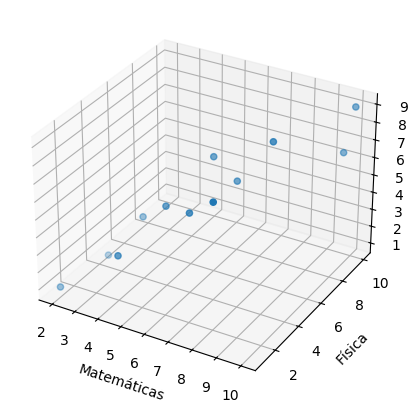

Podemos comprobar que resulta complicado ver relación en 3 dimensiones, así que imagina problemas reales donde se puede trabajar con cientos o incluso mayor número de variables (aunque existen métodos para visualizar datos de múltiples dimensiones).

Gracias a las matemáticas y al cómputo por ordenador, podemos procesar grandes cantidades de datos en múltiples dimensiones de forma eficiente. Nuestro objetivo es crear un modelo que relacione las notas de matemáticas y físicas con la nota correspondiente en PAU. Los datos de partida son los que alimentarán el modelo.

Una vez creado el modelo, los datos observables serán las notas de física y matemáticas y la variable "objetivo" es la nota en PAU. A través de nuevas observaciones (las notas de un alumno en matemáticas y física) más el uso del modelo creado, vamos a inferir que nota tendrá en la prueba de acceso a la universidad.

# Matrices<a href="#Matrices" class="anchor-link">¶</a>

El uso de **matrices** nos va a permitir **representar y procesar** los datos multidimensionales que disponemos para crear nuestro modelo de aprendizaje automático, en este caso, regresión lineal.

Recuerda que una matriz es una tabla numérica rectangular, formada por filas y columnas. Por ejemplo, una matriz de 2x2

\begin{equation}
\begin{bmatrix}
1 & 2\\
3 & 4
\end{bmatrix}
\end{equation}

Gracias NumPy podemos operar matrices de forma fácil y eficiente.

Con la función de numpy.array creamos las matrices con la siguiente sintaxtis:
`A = np.array ( [fila1, fila2, fila3, ...] )` Siendo cada fila y vector numérico entre corchetes.

In \[32\]:

    # Creación de matriz con Numpy y asignación a variable A
    A = np.array([[1,2], [3,4]])
    B = np.array ([[2,3], [3,1]])

    # Si recorremos en un bucle for vemos que, efectivamente, A es un vector de vectores.
    linea = 1
    for a in A:
        print("Línea", linea, a) 
        linea= linea + 1

    Línea 1 [1 2]
    Línea 2 [3 4]

In \[33\]:

    # Podemos acceder a la fila de una matriz mediante su índice, comenzando por 0.
    # Accedemos a la primera fila de la matriz A [1,2]
    print(A[0])

    [1 2]

In \[34\]:

    # También podemos acceder elemento a elemento proporcionando el número de fila y el número de columna
    # Accedemos al elemento de la primera fila, segunda columna, de la matriz A
    print(A[0][1])

    # También podemos usar notación i,j
    print(A[0, 1])

    2
    2

Podemos crear programas en Python para operar con matrices de la misma manera en la que operamos sobre el papel. Por ejemplo, para efectuar la suma A+B, recorremos manualmente elemento a elemento para sumar ambas matrices.

In \[35\]:

    # Vamos a sumar los elementos de matrices cuadradas de 2x2
    filas=2
    columnas=2
    # Recorremos las matrices mediante los índices [i][j]
    for i in range(filas):
        for j in range(columnas):
            # Sumamos y mostramos el resultado
            print(A[i][j]+B[i][j])

    3
    5
    6
    5

# Operaciones con matrices<a href="#Operaciones-con-matrices" class="anchor-link">¶</a>

El código anterior sirve como ejemplo de recorrido de una matriz mediante el uso de bucles "for" en Python.

Operar con matrices es mucho más fácil gracias Numpy:

-   Sumar y Restar: operadores aritméticos + -
-   Multiplicación matricial: símgolo @
-   Traspuesta de A: A.T
-   Inversa de A: función numpy.linalg.inv(A)

In \[36\]:

    A=np.array([[1, 1], [2, 3]])
    B=np.array([[1, 2], [2, 2]])
    print("Matriz A: \n", A, "\n")
    print("Matriz B: \n", B, "\n")

    #Multiplicar matrices
    print(f"Multiplicación de A y B:\n {A @ B}\n")

    #Traspuesta de una matriz
    print(f"Matriz traspuesta A:\n {A.T}\n")

    #Inversa de una matriz
    invA = np.linalg.inv(A)
    print(f"Inversa de A:\n {invA}\n")

    Matriz A: 
     [[1 1]
     [2 3]] 

    Matriz B: 
     [[1 2]
     [2 2]] 

    Multiplicación de A y B:
     [[ 3  4]
     [ 8 10]]

    Matriz traspuesta A:
     [[1 2]
     [1 3]]

    Inversa de A:
     [[ 3. -1.]
     [-2.  1.]]

# Representación de los datos en forma de Matriz<a href="#Representaci%C3%B3n-de-los-datos-en-forma-de-Matriz" class="anchor-link">¶</a>

Vamos a cambiar la notación para referirnos a nuestros datos, recuerda que disponemos de:

-   Nota de matemáticas: x1 = \[2,3,4,4,5,6,6,7,7,8,10,10\]
-   Nota de física: x2 = \[1,3,2,4,4,4,6,4,6,7,9,10\]
-   PAU: y = \[1,2,3,4,5,5,7,6,6,8,7,9\]

Las variables de partida, notas de matemáticas y físicas, serán almacenadas en una matriz, de manera de que cada **columna** corresponde a una **característica** (asignatura) y cada **fila** corresponde a un **alumno**.

Tenemos 12 alumnos y 2 asignaturas. De esta manera, los datos serán almacenados en la variable X, matriz de 12x2.
\$ \begin{equation} X =
\begin{bmatrix}
2 & 1 \\
3 & 3 \\
4 & 2 \\
4 & 4 \\
5 & 4 \\
6 & 4 \\
6 & 6 \\
7 & 4 \\
7 & 6 \\
8 & 7 \\
10 & 9 \\
10 & 10 \\
\end{bmatrix}
\end{equation} \$

La variable 'y' será un vector o matriz fila de tamaño 1x12 que almacenará la variable objetivo, en este caso, nota de PAU.
\$ \begin{equation} y = \[1,2,3,4,5,5,7,6,6,8,7,9\] \end{equation} \$

In \[37\]:

    # Datos originales
    x1 = np.array([2,3,4,4,5,6,6,7,7,8,10,10])
    x2 = np.array([1,3,2,4,4,4,6,4,6,7,9,10])
    y = np.array([1,2,3,4,5,5,7,6,6,8,7,9])
    # Construimos la matriz X a través de x1 y x2. Como NumPy interpreta (x1, x2) como 2 filas, debemos hacer la traspuesta
    X = np.array((x1, x2)).T
    print(f"Matriz de características 12x2 (12 alumnos, 2 características):\n {X}\n")

    # Vector y
    y=np.array([1,2,3,4,5,5,7,6,6,8,7,9])
    print("\n Nota obtenida en PAU (1x12): y =", y)

    Matriz de características 12x2 (12 alumnos, 2 características):
     [[ 2  1]
     [ 3  3]
     [ 4  2]
     [ 4  4]
     [ 5  4]
     [ 6  4]
     [ 6  6]
     [ 7  4]
     [ 7  6]
     [ 8  7]
     [10  9]
     [10 10]]


     Nota obtenida en PAU (1x12): y = [1 2 3 4 5 5 7 6 6 8 7 9]

# Regresión Lineal Múltiple<a href="#Regresi%C3%B3n-Lineal-M%C3%BAltiple" class="anchor-link">¶</a>

Recordemos que en problemas de regresión lineal simple disponemos de una distribución bidimensional y tratamos de encontrar la recta de regresión que mejor se ajusta a los datos. La ecuación de la recta es \$𝑦=𝐴+𝐵𝑥\$ siendo:

-   A Término independiente
-   B Pendiente
-   x variable independiente
-   y variable dependiente

**El entrenamiento del modelo** consistia en encontrar los parámetros A y B que mejor se ajustaran a los datos.

Para este problema, vamos a cambiar la notación ligeramente:

-   A será \$w_0\$
-   B será \$w_1\$

De esta manera, la recta es \$y = w_0 + w_1 x_1\$.

Así del el modelo puede **extenderse a más variables**, siendo en este caso nota de matemáticas \$x_1\$ y física \$x_2\$.

\$y = w_0 + w_1 x_1 + w_2 x_2\$.

La ecucación anterior puede verse como una multiplicación de un vector fila *'x'* (añadiendo un 1 en la primera posición) y un vector columna *'w'*:
\begin{equation} y =
\begin{bmatrix}
1 & x_1 & x_2
\end{bmatrix}
\begin{bmatrix}
w_0 \\ w_1 \\ w_2
\end{bmatrix} = w_0 + w_1 x_1 + w_2 x_2
\end{equation}

**Así es como se realizará la inferencia**. Habiendo calculado los coeficientes *'w'*, teniendo un nuevo alumno y sus notas en *'x'*, hacemos la multiplicación y obtenemos *'y'*.

Generalizando para 'k' variables (características) \$y = w_0 + w_1 x_1 + w_2 x_2 + ... + w_k x_k\$

Pero antes debemos calcular los coeficientes partiendo de los datos de todos los alumnos.

Podemos usar la notación matricial para representar todos los datos. Teniendo **k características** y **n observaciones** (individuos), obtenemos las siguientes matrices:

-   Matriz 'X' de características de n filas (n=instancias) y k+1 columnas (k=características)
-   Vector columna 'y' que almacena los datos de la variable objetivo
-   Vector columa 'w' de coeficientes a calcular.

\$ \begin{equation} X =
\begin{bmatrix}
1 & x\_{11} & x\_{12} & ... & x\_{1k} \\
1 & x\_{21} & x\_{22} & ... & x\_{2k}\\
1 & x\_{31} & x\_{32} & ... & x\_{3k}\\
1 & ... & ... & ... & ... \\
1 & x\_{n1} & x\_{n2} & ... & x\_{nk}
\end{bmatrix}
\end{equation} \$

\$ \begin{equation} y =
\begin{bmatrix}
y_1 \\
y_2 \\
y_3 \\
... \\
y_n
\end{bmatrix}
\end{equation} \$

\$ \begin{equation} w =
\begin{bmatrix}
w_0 \\
w_1 \\
w_2 \\
... \\
w_k
\end{bmatrix}
\end{equation} \$

De modo matricial, la ecuación queda representada de la siguiente manera \$y=X w\$.

Como se puede observar, a la matriz X se le añade una columna de '1' para ajustar la multiplicación con el coeficiente \$w_0\$

**En resumen**: Para crear nuestro modelo partimos de los datos:

-   Matriz X, donde cada columna corresponde con una característica (nota de matemáticas y nota de física) y cada fila a un alumno. Además, hay que añadir una columna de '1' al principio.
-   El vector y, variable objetivo, nota PAU.

In \[38\]:

    # Ya disponemos en X los datos de una celda anterior
    print(f"Matriz de características 12x2 (12 alumnos, 2 características):\n {X}\n")

    # Vamos a añadir una columna de '1'
    # Con la función de Numpy.ones(filas, columnas) creamos una matriz de unos de tamaño 12x1.
    M1 = np.ones((12,1), dtype=int)
    # Con la función Numpy.append añadimos la matriz creada a nuestros datos.
    X = np.append(M1, X, 1)
    print(f"Matriz 12x3:\n {X}")

    Matriz de características 12x2 (12 alumnos, 2 características):
     [[ 2  1]
     [ 3  3]
     [ 4  2]
     [ 4  4]
     [ 5  4]
     [ 6  4]
     [ 6  6]
     [ 7  4]
     [ 7  6]
     [ 8  7]
     [10  9]
     [10 10]]

    Matriz 12x3:
     [[ 1  2  1]
     [ 1  3  3]
     [ 1  4  2]
     [ 1  4  4]
     [ 1  5  4]
     [ 1  6  4]
     [ 1  6  6]
     [ 1  7  4]
     [ 1  7  6]
     [ 1  8  7]
     [ 1 10  9]
     [ 1 10 10]]

# Regresión Lineal y MSE<a href="#Regresi%C3%B3n-Lineal-y-MSE" class="anchor-link">¶</a>

Nuestro problema consiste en encontrar el vector de coeficientes \$w\$ que mejor se ajusta a los datos.

Una de las funciones de coste básicas en aprendizaje automático es MSE (mean squared error o error cuadrático medio), calculado como la media de los errores al cuadrado entre el valor de **'y' real** y el valor **'y' predicho**.

\$ MSE = \frac {1} {n} \sum ({y_i - y_i^{\prime}})^2 \$

La fórmula para calcular los coeficientes ***w*** minimizando el error cuadrático medio es: \$w=(X^{T}X)^{-1}X^{T}y\$

------------------------------------------------------------------------

Vamos a calcular *w* paso a paso

Hacemos \$(X^{T}X)\$

In \[39\]:

    # Usaremos X' como notación de traspuesta de X
    # Calculamos X'X. X' tiene un tamaño de 3x12 y X de 12x3, el resultado será una matriz de 3x3
    Ra = X.T @ X
    print(Ra)

    [[ 12  72  60]
     [ 72 504 431]
     [ 60 431 380]]

Hacemos \$(X^{T}X)^{-1}\$ inviertno el resultado anterior

In \[40\]:

    # Intevertimos Ra para calcular la inversa de (X'X). Hacemos uso de la función de Numpy linalg.inv(matriz)
    Ra_invertida = np.linalg.inv(Ra)
    print(Ra_invertida)

    [[ 0.66747798 -0.17385257  0.09179416]
     [-0.17385257  0.11126565 -0.09874826]
     [ 0.09179416 -0.09874826  0.10013908]]

Hacemos \$(X^{T}X)^{-1}X^{T}\$ multiplicando el resultado anterior por X.T

In \[41\]:

    # Multiplicamos Ra_invertida por X'.
    # Ra_invertida es 3x3, X' es 3x12, resultado es 3x12
    Rb = Ra_invertida @ X.T
    print(Rb)

    [[ 0.41156699  0.42130274  0.155656    0.33924432  0.16539175 -0.00846083
       0.17512749 -0.1823134   0.00127492 -0.0807835  -0.24490032 -0.15310617]
     [-0.05006954 -0.13630042  0.07371349 -0.12378303 -0.01251739  0.09874826
      -0.09874826  0.21001391  0.01251739  0.02503477  0.05006954 -0.04867872]
     [-0.00556328  0.09596662 -0.10292072  0.09735744 -0.00139082 -0.10013908
       0.10013908 -0.19888734  0.00139082  0.00278164  0.00556328  0.10570236]]

Finalmente hacemos \$w=(X^{T}X)^{-1}X^{T}y\$ multiplicando el resultado anterior por *y*

In \[42\]:

    # Multiplicamos Rb por y
    # Rb es 3x12 e 'y' es 12x1, resultado es final w es de tamaño 3x1
    w = Rb @ y
    print("Los coeficientes de nuestro modelo son:", w)

    Los coeficientes de nuestro modelo son: [0.26390821 0.59109875 0.28789986]

Hacemos el mismo calculo en una sola línea \$w=(X^{T}X)^{-1}X^{T}y\$

In \[43\]:

    # Podemos realizar el mismo cálculo es una sola línea
    w=np.linalg.inv(X.T @ X) @ X.T @ y
    print("Los coeficientes de nuestro modelo son:")
    print(f" - w0 = {w[0]}")
    print(f" - w1 = {w[1]}")
    print(f" - w2 = {w[2]}")

    Los coeficientes de nuestro modelo son:
     - w0 = 0.2639082058414547
     - w1 = 0.5910987482614778
     - w2 = 0.2878998609179426

# Inferencia<a href="#Inferencia" class="anchor-link">¶</a>

Una vez obtenidos los parámetros de nuestro modelo, es muy sencillo realizar inferencia.

Tan solo tenemos que realizar la multiplicación de las características observadas por el vector de coeficientes (añadiendo un 1 al vector de características observadas).

\begin{equation} y =
\begin{bmatrix}
1 & x_1 & x_2
\end{bmatrix}
\begin{bmatrix}
w_0 \\ w_1 \\ w_2
\end{bmatrix} = w_0 + w_1 x_1 + w_2 x_2
\end{equation}

**Ejemplo** : Un nuevo alumno obtiene:

-   7 en matemáticas
-   6 en física

El vector es `x = [1, 7, 6]`

La nota prevista en PAU será:

In \[44\]:

    # Creamos el vector de características observadas con la función array de Numpy, añadiendo el 1 en la primera posición.
    x_nuevo = np.array([1,7,6])

    # Multiplicamos x_nuevo por el vector de coeficientes para obtener la predicción.
    nota_predicha = x_nuevo @ w
    print("La predicción para PAU es de:", round(nota_predicha, 2))

    La predicción para PAU es de: 6.13

# Regresión lineal con Scikit-Learn<a href="#Regresi%C3%B3n-lineal-con-Scikit-Learn" class="anchor-link">¶</a>

Existen bibliotecas específicas de aprendizaje automático que nos permiten construir modelos de forma sencilla, como el que acabamos de construir, además de muchos otros, con ciertas variantes en cuanto a funciones de coste.

Vamos a crear el mismo modelo mediante la biblioteca Scikit-Learn.

In \[45\]:

    # Importamos la biblioteca, específicamente el módulo LinearRegression
    from sklearn.linear_model import LinearRegression


    # Datos originales
    x1 = np.array([2,3,4,4,5,6,6,7,7,8,10,10])
    x2 = np.array([1,3,2,4,4,4,6,4,6,7,9,10])
    y = np.array([1,2,3,4,5,5,7,6,6,8,7,9])
    # Matriz X (no hace falta añadir la columna de unos al usar Scikit-Learn)
    X = np.array((x1, x2)).T
    # Vector objetivo y
    y=np.array([1,2,3,4,5,5,7,6,6,8,7,9])

    # Instanciamos el modelo de regresión lineal
    modelo = LinearRegression()

    # Entrenamos el modelo con los datos de partida
    modelo.fit(X, y)

    # EL MODELO ESTÁ CREADO Y LISTO PARA USAR

    # En modelo.intercept_ tenemos el valor w0
    print("w0 = ", modelo.intercept_)
    # En modelo.coef_ el resto de coeficientes
    print("Coeficientes:", modelo.coef_)

    # Para predecir nuevos valores, usamos la función predict(vector), nuevamente, sin necesidad de añadir la columna con un 1 al inicio
    x_nuevo = np.array([[7, 6]])
    nota_predicha = modelo.predict(x_nuevo)
    print("La predicción para PAU es de:", round(nota_predicha[0], 2)) 

    w0 =  0.26390820584144503
    Coeficientes: [0.59109875 0.28789986]
    La predicción para PAU es de: 6.13

# Para practicar y evaluar lo aprendido<a href="#Para-practicar-y-evaluar-lo-aprendido" class="anchor-link">¶</a>

Visualiza la presentación (ejecuta la celda si no está visible) y responde al Quiz ayudandote de la programación en Python

In \[51\]:

    from IPython.display import IFrame
    IFrame('https://view.genially.com/69c120594b74a12d8c3d3345',900,500)

Out\[51\]:

Resuelve cada pregunta de TEST en una celda de código diferente

El dataset a usar es <https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html>

El nuevo individuo a calcular es

`x_nuevo = [-0.09269548, -0.04464164, -0.04069594, -0.01944183, -0.06899065, -0.07928784, 0.04127682, -0.0763945, -0.04117617, -0.09634616]`

In \[47\]:

    A = np.array(([3, 4], [2, 7]))
    B = np.array([2, 3])

    print(B @ np.linalg.inv(A) @ B.T)

    1.4615384615384612

In \[48\]:

    from sklearn.datasets import load_diabetes
    from sklearn.linear_model import LinearRegression

    X, y = load_diabetes(return_X_y=True)
    modelo = LinearRegression()
    modelo.fit(X, y)
    print(modelo.intercept_)
    print(modelo.coef_[3])

    152.13348416289597
    324.38464550232385

In \[50\]:

    x_nuevo = np.array([[-0.09269548, -0.04464164, -0.04069594, -0.01944183, -0.06899065, -0.07928784, 0.04127682, -0.0763945,  -0.04117617, -0.09634616]])
    print(modelo.predict(x_nuevo))

    [106.35191425]